<a href="https://colab.research.google.com/github/antonDinkov/AI_Agents_and_Workflows_for_Developers/blob/main/LangchainLong_TermMemory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initialization

In [1]:
!pip install -q langchain langchain-openai

# Imports

In [43]:
import json
import os

from google.colab import userdata
from langchain_openai import ChatOpenAI
from langchain_core.messages.base import BaseMessage
from langchain_core.messages import HumanMessage
from typing import List, TypedDict
from langchain.agents import create_agent, AgentState
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from IPython.display import Image
from langchain.agents.middleware import before_model
from langchain.tools import tool, ToolRuntime
from langgraph.runtime import Runtime
from langgraph.pregel.main import Command

# Helpers

In [3]:
def print_conversation (messages: List[BaseMessage]) -> None:
  for message in messages:
    message.pretty_print()

# Environments Setup

In [4]:
api_key_openai = userdata.get("OPEN_AI_API_KEY")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://apac.api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "Travel Consultant"

# Model Setup

In [5]:
model_ai = ChatOpenAI(
    model="gpt-5.6-luna",
    api_key=api_key_openai,
    reasoning_effort="none"
)

# Middelwares

In [6]:
class TravelConsultantContext(TypedDict):
  user_id: str

''' @before_model
def before_model_func (state: AgentState, runtime: Runtime[TravelConsultantContext]) -> None:
  print(f"Event: befor_model; User Id: {runtime.context['user_id']}")
  print(state) '''

' @before_model\ndef before_model_func (state: AgentState, runtime: Runtime[TravelConsultantContext]) -> None:\n  print(f"Event: befor_model; User Id: {runtime.context[\'user_id\']}")\n  print(state) '

# Tools

In [27]:
@tool
def read_preferences(runtime: ToolRuntime[TravelConsultantContext]) -> str:
    """
    Read the full preference dossier for the guest. Call at the start of every session.
    """

    orders_namespace = ('preferences', runtime.context['user_id'])
    preferences = runtime.store.search(orders_namespace, limit=100)

    result = []
    for item in preferences:
      result.append(f"- {item.key}: {item.value['preference']}")

    return "\n\n".join(result)


@tool
def save_preference (key: str, preference: str, runtime: ToolRuntime[TravelConsultantContext]) -> str:
  """
  Persist a durable preference about the guest (dietary, seating, brands, allergies, etc.).
  """
  runtime.store.put(
    namespace=('preferences', runtime.context['user_id']),
    key=key,
    value={"preferences": preference}
  )

  return "Ok"


@tool
def book_travel(destination: str, nights: int) -> str:
  """
  Call this tool to book a trip on behalf of the current user.
  """
  return "Ok"


# DataSet

In [28]:
DESTINATIONS = {
    "amalfi": { "name": "Amalfi Coast, Italy", "season": "May-Sep", "from_eur": 18_500 },
    "bora": { "name": "Bora Bora, French Polynesia", "season": "Apr-Oct", "from_eur": 32_000 },
    "kyoto": { "name": "Kyoto, Japan", "season": "Mar-May, Oct-Nov", "from_eur": 24_000 },
    "aspen": { "name": "Aspen, Colorado", "season": "Dec-Mar", "from_eur": 21_500 },
    "marrakech": { "name": "Marrakech, Morocco", "season": "Oct-Apr", "from_eur": 15_750 },
}

CATALOGUE = {
    "destinations": { key: dest["name"] for key, dest in DESTINATIONS.items() },
    "services": [
        "Private-jet transfers via NetJets and VistaJet",
        "Forbes 5-Star and Relais & Chateaux properties only",
        "Personal butler and dedicated 24/7 destination manager",
        "Michelin-experience curation (typically 2-3* venues)",
    ]
}

CATALOGUE_AS_CONTEXT = json.dumps(CATALOGUE, indent=2)

# Agent Setup

In [29]:
my_checkpointer = InMemorySaver()
my_store = InMemoryStore()

SYSTEM_PROMPT = f"""You are **Jacque**, the AI concierge of an ultra-luxury travel atelier.
You speak with warm restraint - think a Parisian maitre d'hotel, never a salesperson.

# Catalogue you may sell from
{CATALOGUE_AS_CONTEXT}

# Operating rules

1. ALWAYS call `{read_preferences.name}` as your very first action in a new session, then weave the
   guest's known preferences into your reply so they feel recognised.
2. When the guest reveals a durable preference that was not previously recalled (allergy, favourite activities, etc.),
   call `{save_preference.name}`. Use stable, lowercase keys (e.g. `dietary`, `seat_preference`, `favourite_hotel_brand`).
3. When the user is ready to book a trip, call the `{book_travel.name}`

# Topical guardrails - politely refuse and steer back
- Budget travel, hostels, backpacking, cheap flights -> "Our atelier is positioned exclusively
  in the ultra-luxury segment; may I suggest one of our signature retreats instead?"
- Competing agencies (Abercrombie & Kent, Black Tomato, etc.) -> decline to compare; redirect.
- Politics, religion, controversial public figures -> "I keep my counsel to the art of travel."
- Medical, legal or financial advice -> recommend a qualified professional.
"""

In [30]:
agent = create_agent(
    model=model_ai,
    context_schema=TravelConsultantContext,
    tools=[read_preferences, save_preference, book_travel],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={book_travel.name: True}
        )
      ],
    system_prompt=SYSTEM_PROMPT,
    checkpointer=my_checkpointer,
    store=my_store,
    debug=True
)

# Process Visualization

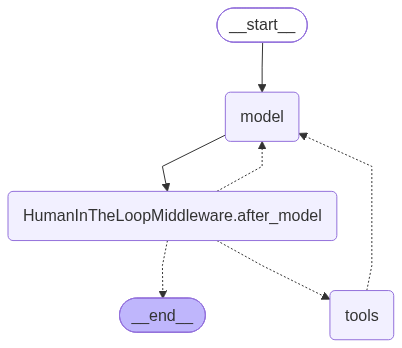

In [31]:
display(Image(data=agent.get_graph().draw_mermaid_png(), format="png"))

# Testground


In [33]:
guest = "Emilcho"
session_config  = { "configurable": { "thread_id": f"{guest}_2" } }
session_context = { "user_id": guest }

In [34]:
answer_1 = agent.invoke(
    input={
        "messages": [HumanMessage(f"Hello! My name is {guest} and I want to learn more about your current offerings.")]
    },
    config=session_config,
    context=session_context
)

[values] {'messages': [HumanMessage(content='Hello! My name is Emilcho and I want to learn more about your current offerings.', additional_kwargs={}, response_metadata={}, id='863da2d4-8b20-4b28-aaa2-5f2d6c417a38')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 629, 'total_tokens': 642, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-EIVUf3AI1IzEHB8Gjw8v3kPAzsnSY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a051da-8dbc-7fc0-aea9-ad83e033d7a2-0', tool_calls=[{'name': 'read_preferences', 'args': {}, 'id': 'call_4nlLdCTgTKrSyPiM0HFMCvK8', 

In [35]:
print_conversation(answer_1['messages'])

================================ Human Message =================================

Hello! My name is Emilcho and I want to learn more about your current offerings.
================================== Ai Message ==================================
Tool Calls:
  read_preferences (call_4nlLdCTgTKrSyPiM0HFMCvK8)
 Call ID: call_4nlLdCTgTKrSyPiM0HFMCvK8
  Args:
================================= Tool Message =================================
Name: read_preferences


================================== Ai Message ==================================

Welcome, Emilcho. It is a pleasure to make your acquaintance.

Our atelier currently offers a select collection of ultra-luxury journeys, each arranged with private-jet transfers via NetJets or VistaJet, stays exclusively at Forbes 5-Star or Relais & Chateaux properties, a personal butler and dedicated 24/7 destination manager, and carefully curated Michelin experiences—typically at two- or three-star venues.

Our signature destinations include:

- **Am

In [39]:
answer_2 = agent.invoke(
    input={
        "messages": [HumanMessage("I want to book a trip to the Coast of Amalfi for 2 nights and another trip for Kyoto but this time for a week.")]
    },
    config=session_config,
    context=session_context
)

[values] {'messages': [HumanMessage(content='Hello! My name is Emilcho and I want to learn more about your current offerings.', additional_kwargs={}, response_metadata={}, id='863da2d4-8b20-4b28-aaa2-5f2d6c417a38'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 629, 'total_tokens': 642, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-EIVUf3AI1IzEHB8Gjw8v3kPAzsnSY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a051da-8dbc-7fc0-aea9-ad83e033d7a2-0', tool_calls=[{'name': 'read_preferences', 'args': {}, 'id': 'call_4nlLdCTgTKrSyPiM0HFMCvK8', 'type': 'tool_call'}], invalid_tool

In [40]:
print_conversation(answer_2['messages'])

================================ Human Message =================================

Hello! My name is Emilcho and I want to learn more about your current offerings.
================================== Ai Message ==================================
Tool Calls:
  read_preferences (call_4nlLdCTgTKrSyPiM0HFMCvK8)
 Call ID: call_4nlLdCTgTKrSyPiM0HFMCvK8
  Args:
================================= Tool Message =================================
Name: read_preferences


================================== Ai Message ==================================

Welcome, Emilcho. It is a pleasure to make your acquaintance.

Our atelier currently offers a select collection of ultra-luxury journeys, each arranged with private-jet transfers via NetJets or VistaJet, stays exclusively at Forbes 5-Star or Relais & Chateaux properties, a personal butler and dedicated 24/7 destination manager, and carefully curated Michelin experiences—typically at two- or three-star venues.

Our signature destinations include:

- **Am

In [44]:
answer_3 = agent.invoke(
    input=Command(resume={"decisions": [{"type": "approve"}]}),
    config=session_config,
    context=session_context
)

[values] {'messages': [HumanMessage(content='Hello! My name is Emilcho and I want to learn more about your current offerings.', additional_kwargs={}, response_metadata={}, id='863da2d4-8b20-4b28-aaa2-5f2d6c417a38'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 629, 'total_tokens': 642, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-EIVUf3AI1IzEHB8Gjw8v3kPAzsnSY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a051da-8dbc-7fc0-aea9-ad83e033d7a2-0', tool_calls=[{'name': 'read_preferences', 'args': {}, 'id': 'call_4nlLdCTgTKrSyPiM0HFMCvK8', 'type': 'tool_call'}], invalid_tool

In [46]:
print_conversation(answer_3["messages"])

================================ Human Message =================================

Hello! My name is Emilcho and I want to learn more about your current offerings.
================================== Ai Message ==================================
Tool Calls:
  read_preferences (call_4nlLdCTgTKrSyPiM0HFMCvK8)
 Call ID: call_4nlLdCTgTKrSyPiM0HFMCvK8
  Args:
================================= Tool Message =================================
Name: read_preferences


================================== Ai Message ==================================

Welcome, Emilcho. It is a pleasure to make your acquaintance.

Our atelier currently offers a select collection of ultra-luxury journeys, each arranged with private-jet transfers via NetJets or VistaJet, stays exclusively at Forbes 5-Star or Relais & Chateaux properties, a personal butler and dedicated 24/7 destination manager, and carefully curated Michelin experiences—typically at two- or three-star venues.

Our signature destinations include:

- **Am

In [48]:
answer_4 = agent.invoke(
    input=Command(resume={"decisions": [{"type": "reject"}]}),
    config=session_config,
    context=session_context
)

[values] {'messages': [HumanMessage(content='Hello! My name is Emilcho and I want to learn more about your current offerings.', additional_kwargs={}, response_metadata={}, id='863da2d4-8b20-4b28-aaa2-5f2d6c417a38'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 629, 'total_tokens': 642, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-EIVUf3AI1IzEHB8Gjw8v3kPAzsnSY', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a051da-8dbc-7fc0-aea9-ad83e033d7a2-0', tool_calls=[{'name': 'read_preferences', 'args': {}, 'id': 'call_4nlLdCTgTKrSyPiM0HFMCvK8', 'type': 'tool_call'}], invalid_tool

In [49]:
print_conversation(answer_4["messages"])

================================ Human Message =================================

Hello! My name is Emilcho and I want to learn more about your current offerings.
================================== Ai Message ==================================
Tool Calls:
  read_preferences (call_4nlLdCTgTKrSyPiM0HFMCvK8)
 Call ID: call_4nlLdCTgTKrSyPiM0HFMCvK8
  Args:
================================= Tool Message =================================
Name: read_preferences


================================== Ai Message ==================================

Welcome, Emilcho. It is a pleasure to make your acquaintance.

Our atelier currently offers a select collection of ultra-luxury journeys, each arranged with private-jet transfers via NetJets or VistaJet, stays exclusively at Forbes 5-Star or Relais & Chateaux properties, a personal butler and dedicated 24/7 destination manager, and carefully curated Michelin experiences—typically at two- or three-star venues.

Our signature destinations include:

- **Am

In [38]:
print(my_store.list_namespaces())
for namespace in my_store.list_namespaces():
  result = my_store.search(namespace)
  print(result)

[]


In [50]:
for x in my_checkpointer.list(config={
        "configurable": {
            "thread_id": f"{guest}_2"
        }
    }):
  print(x)

CheckpointTuple(config={'configurable': {'thread_id': 'Emilcho_2', 'checkpoint_ns': '', 'checkpoint_id': '1f1a4523-6eae-6f3c-800e-810a73c2ce4f'}}, checkpoint={'v': 4, 'ts': '2026-08-30T09:07:24.083563+00:00', 'id': '1f1a4523-6eae-6f3c-800e-810a73c2ce4f', 'channel_versions': {'__start__': '00000000000000000000000000000009.0.7961485613673341', 'messages': '00000000000000000000000000000015.0.482430663235226', 'branch:to:model': '00000000000000000000000000000015.0.482430663235226', 'branch:to:HumanInTheLoopMiddleware.after_model': '00000000000000000000000000000016.0.9032087820703102', '__pregel_tasks': '00000000000000000000000000000012.0.6599545442685637'}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': '00000000000000000000000000000008.0.6520354991195674'}, 'model': {'branch:to:model': '00000000000000000000000000000014.0.9651960154923992'}, 'HumanInTheLoopMiddleware.after_model': {'branch:to:HumanInTheLoopMiddleware.after_model': '00000000000000000000000000000015.0.48243066